In [1]:
import torch
import model
import lancedb
import os
from hydra import initialize, initialize_config_module, initialize_config_dir, compose
from omegaconf import OmegaConf
from dotenv import load_dotenv
from datafusion import functions as f
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
import numpy as np
from PIL import Image
from torchvision import transforms
import multiprocessing
import trackio
from tqdm.auto import tqdm

In [2]:
with initialize(version_base=None, config_path="conf"):
    load_dotenv()
    write_url = os.environ["TRACKIO_WRITE_URL"]
    cfg = compose(config_name="config", overrides=[f'trackio.write_url="{write_url}"'])
    trackio.init(name=cfg.trackio.run_name, project=cfg.trackio.project, server_url=cfg.trackio.write_url, config={"epochs": cfg.training.rnn.nb_epochs, "learning_rate": cfg.training.rnn.lr})

* Trackio project initialized: ha_schmidhuber
* Trackio metrics will be sent to self-hosted server: https://trackio.flydexo.com


* Apple Silicon detected, enabling automatic GPU/system metrics logging
* psutil detected, enabling automatic CPU/system metrics logging
* Created new run: <10k


In [3]:
vae = model.AutoEncoder(cfg).to(cfg.device)
vae.load_state_dict(torch.load(f'./vae-{cfg.trackio.run_name}.pt', weights_only=True))
vae.eval()

AutoEncoder(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2))
    (7): ReLU()
  )
  (dense): Dense(
    (mu): Linear(in_features=1024, out_features=32, bias=True)
    (log_sigma): Linear(in_features=1024, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=1024, bias=True)
    (1): Fit()
    (2): ConvTranspose2d(1024, 128, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2))
    (5): ReLU()
    (6): ConvTranspose2d(64, 32, kernel_size=(6, 6), stride=(2, 2))
    (7): ReLU()
    (8): ConvTranspose2d(32, 3, kernel_size=(6, 6), stride=(2, 2))
    (9): Sigmoid()
  )
)

In [4]:
rnn = model.RNN(cfg).to(cfg.device)

In [5]:
class FullEpisodicDataset(torch.utils.data.Dataset):
    def __init__(self, cfg):
        super().__init__()
        self.lancedb_uri = cfg.dataset.lancedb_uri
        self.img_size = cfg.dataset.img_size
        self._table = None
        self._len = lancedb.connect(cfg.dataset.lancedb_uri).open_table("episodes").count_rows()

    def _get_table(self):
        if self._table is None:
            self._table = lancedb.connect(self.lancedb_uri).open_table("episodes")
        return self._table

    def __getitem__(self, idx):
        episode = self._get_table().search().where(f'episode_id = {idx}').limit(1).to_arrow()
        frames_np = np.array(episode.column('observations').combine_chunks()[0].as_py(), dtype=np.uint8).reshape(-1, self.img_size, self.img_size, 3)
        actions_np = np.array(episode.column('actions').combine_chunks()[0].as_py(), dtype=np.float32)
        obs = torch.from_numpy(frames_np).clone().permute(0, 3, 1, 2).to(torch.float32) / 255
        acts = torch.from_numpy(actions_np).clone()
        return obs, acts

    def __len__(self):
        return self._len


class ZDataset(torch.utils.data.Dataset):
    """Pre-computed VAE μ encodings — lives entirely in CPU RAM (~38 MB for 1k episodes)."""
    def __init__(self, z_list, a_list):
        self.z = z_list
        self.a = a_list

    def __len__(self):
        return len(self.z)

    def __getitem__(self, idx):
        return self.z[idx], self.a[idx]


def collate_padded(batch):
    """Pad variable-length episodes; return a boolean mask for valid (non-padded) timesteps."""
    z_list, a_list = zip(*batch)
    T_list = [z.shape[0] - 1 for z in z_list]   # number of valid input/target pairs
    T_max  = max(T_list)
    B, z_dim, a_dim = len(batch), z_list[0].shape[-1], a_list[0].shape[-1]

    z_in  = torch.zeros(B, T_max, z_dim)
    a_in  = torch.zeros(B, T_max, a_dim)
    z_tgt = torch.zeros(B, T_max, z_dim)
    mask  = torch.zeros(B, T_max, dtype=torch.bool)

    for i, (z, a, T) in enumerate(zip(z_list, a_list, T_list)):
        z_in[i,  :T] = z[:-1]
        a_in[i,  :T] = a[:T]
        z_tgt[i, :T] = z[1:]
        mask[i,  :T] = True

    return z_in, a_in, z_tgt, mask

In [6]:
ds = FullEpisodicDataset(cfg)
train_ds, valid_ds = random_split(ds, [0.9, 0.1])

# ── Pre-compute VAE μ for all episodes (once, before training) ─────────────────────────────────
# This eliminates repeated VAE inference across 20 epochs (~18k forward passes saved).
# All 1k episodes fit in ~38 MB of RAM.
num_workers_pre = min(6, multiprocessing.cpu_count() - 1)
_pre_kwargs = dict(
    batch_size=1, collate_fn=lambda b: b[0],
    num_workers=num_workers_pre, persistent_workers=num_workers_pre > 0,
    prefetch_factor=4 if num_workers_pre > 0 else None,
    multiprocessing_context='fork' if num_workers_pre > 0 else None,
)

vae.eval()
z_cache, a_cache = [], []
with torch.no_grad():
    for obs, acts in tqdm(DataLoader(ds, **_pre_kwargs), desc="Pre-computing z"):
        T = min(obs.shape[0], acts.shape[0])
        _, mu_z, _ = vae.encode(obs[:T].to(cfg.device))   # use μ, not stochastic sample
        z_cache.append(mu_z.cpu())
        a_cache.append(acts[:T].cpu())

z_ds = ZDataset(z_cache, a_cache)
train_z_ds, val_z_ds = random_split(z_ds, [0.9, 0.1])
print(f"Pre-computed {len(z_cache)} episodes — {len(train_z_ds)} train / {len(val_z_ds)} val")

/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  self.pid = os.fork()
/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  self.pid = os.fork()
/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/multiprocessing/

Pre-computing z:   0%|          | 0/5700 [00:00<?, ?it/s]

Pre-computed 5700 episodes — 5130 train / 570 val


In [7]:
# Image DataLoader — kept for the diagnostic cells below (sigma check, image display)
num_workers = min(6, multiprocessing.cpu_count() - 1)
_img_kwargs = dict(
    batch_size=4, collate_fn=lambda b: b[0],
    num_workers=num_workers, persistent_workers=num_workers > 0,
    prefetch_factor=4 if num_workers > 0 else None,
    multiprocessing_context='fork' if num_workers > 0 else None,
)
train_loader = DataLoader(train_ds, **_img_kwargs)
val_loader   = DataLoader(valid_ds, **_img_kwargs)

# Z DataLoader — batched, in-memory, used for the actual training loop
BATCH_SIZE = 32
_z_kwargs = dict(batch_size=BATCH_SIZE, collate_fn=collate_padded, num_workers=0)
train_z_loader = DataLoader(train_z_ds, shuffle=True,  **_z_kwargs)
val_z_loader   = DataLoader(val_z_ds,   shuffle=False, **_z_kwargs)

In [8]:
with torch.no_grad():
    sample_obs = next(iter(train_loader))[0].to(cfg.device)
    regen, _ = vae(sample_obs)
    _, _, log_sigma = vae.encode(sample_obs[:10])
    print("mean VAE sigma:", torch.exp(log_sigma).mean().item())
    print("mean VAE sigma per dim:", torch.exp(log_sigma).mean(0))

/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  self.pid = os.fork()
/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  self.pid = os.fork()
/Users/matheoledevehat/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/multiprocessing/

mean VAE sigma: 0.8879355788230896
mean VAE sigma per dim: tensor([0.9422, 0.0993, 0.9742, 0.1980, 1.0126, 0.9813, 0.9716, 0.9643, 0.9268,
        0.9848, 0.5421, 0.4445, 0.8971, 0.9777, 0.9717, 0.9963, 0.9948, 0.9712,
        0.9454, 0.9670, 0.9631, 0.9781, 0.9995, 0.9977, 0.9185, 0.9931, 0.9409,
        0.9714, 0.9171, 1.0080, 0.9905, 0.9731], device='mps:0')


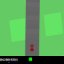

In [9]:
Image.fromarray((sample_obs*255).to(torch.uint8)[251].permute(1,2,0).cpu().numpy())

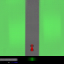

In [10]:
Image.fromarray((regen*255).to(torch.uint8)[251].permute(1,2,0).cpu().numpy())

In [11]:
optimizer = torch.optim.AdamW(rnn.parameters(), cfg.training.rnn.lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, cfg.training.rnn.nb_epochs)

for epoch in range(cfg.training.rnn.nb_epochs):
    rnn.train()
    for z_in, a_in, z_tgt, mask in train_z_loader:
        z_in  = z_in.to(cfg.device)   # (B, T, 32)
        a_in  = a_in.to(cfg.device)   # (B, T, 3)
        z_tgt = z_tgt.to(cfg.device)  # (B, T, 32)
        mask  = mask.to(cfg.device)   # (B, T) bool

        pi, mu, sigma, _, rnn_out = rnn(z_in, a_in)
        loss = model.MDN.loss(pi, mu, sigma, z_tgt, mask) + rnn_out[mask].pow(2).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rnn.parameters(), max_norm=1.0)
        optimizer.step()
        trackio.log({"rnn-training-loss": loss.item()})

    rnn.eval()
    with torch.no_grad():
        for z_in, a_in, z_tgt, mask in val_z_loader:
            z_in  = z_in.to(cfg.device)
            a_in  = a_in.to(cfg.device)
            z_tgt = z_tgt.to(cfg.device)
            mask  = mask.to(cfg.device)
            pi, mu, sigma, _, _ = rnn(z_in, a_in)
            loss = model.MDN.loss(pi, mu, sigma, z_tgt, mask)
            trackio.log({"rnn-val-loss": loss.item()})

    scheduler.step()

In [12]:
trackio.finish()

* Run finished. Uploading logs to the remote Trackio server (please wait...)


/Users/matheoledevehat/Code/worldmodels/ha_schmidhuber/.venv/lib/python3.11/site-packages/trackio/utils.py:27: UserWarning: * Some logs could not be sent to the remote server (it may still be starting up). They have been saved locally and will be sent automatically next time you call: trackio.init(project="ha_schmidhuber", server_url="https://trackio.flydexo.com")
  warnings.warn(message, *args, **kwargs)


In [13]:
torch.save(rnn.state_dict(), f'./rnn-{cfg.trackio.run_name}.pt')